# 对风电场多风机进行聚类

In [1]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# 设置中文字体
# 设置中文字体
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
from matplotlib.colors import ListedColormap

def draw_cluster(labels, n_clusters):
    locations = pd.read_csv("sdwpf_baidukddcup2022_turb_location.CSV")
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        locations['x'], locations['y'], c=labels, cmap='Set1', s=50, edgecolor='k'
    )
    # 给每个风机标上TurbID
    for i, row in locations.iterrows():
        plt.text(row['x'], row['y'], str(int(row['TurbID'])), fontsize=9, ha='right', va='bottom')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('风机聚类结果')
    # 只显示n_clusters个颜色
    cmap = ListedColormap(plt.get_cmap('Set1').colors[:n_clusters])
    scatter.set_cmap(cmap)
    plt.colorbar(scatter, ticks=range(n_clusters), label='Cluster')
    plt.show()


## 一. 利用Pearson相关性及K-means进行聚类

聚类标签: [2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 0 0 1 0 0
 2 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 0 0 0 2 2 1 1 2 2 2 2 2 2 2 2 2 2 2 0
 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


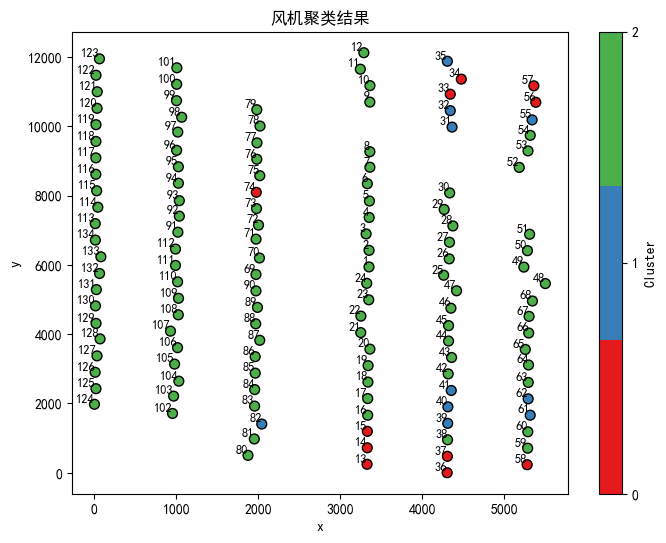

In [3]:
wind_speed_correlation_matrices = np.load("wind_speed_correlation_matrices.npz")["original"]

# 设定聚类数目
n_clusters = 3

# 使用K-means进行聚类
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(wind_speed_correlation_matrices)

print("聚类标签:", labels)
draw_cluster(labels, n_clusters)


## 二. 利用一阶差分Person相关性及K-means进行聚类
### 计算一阶差分
```python
diff_data = np.diff(self.wind_speed_data, axis=1)
print(f"差分数据形状: {diff_data.shape}")
```

聚类标签: [0 0 1 0 0 0 0 2 2 2 2 2 2 2 2 1 1 1 1 1 1 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2
 2 1 1 1 1 1 1 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 0 0 0 0 0 0
 0 3 0 3 3 3 3 3 3 3 1 1 1 1 1 1 0 0 0 3 3 3 3 3 3 3 3 3 3 3 1 1 1 1 1 1 1
 1 0 0 3 3 3 3 3 3 3 3 3 3 3 1 1 1 1 1 1 1 1 1]


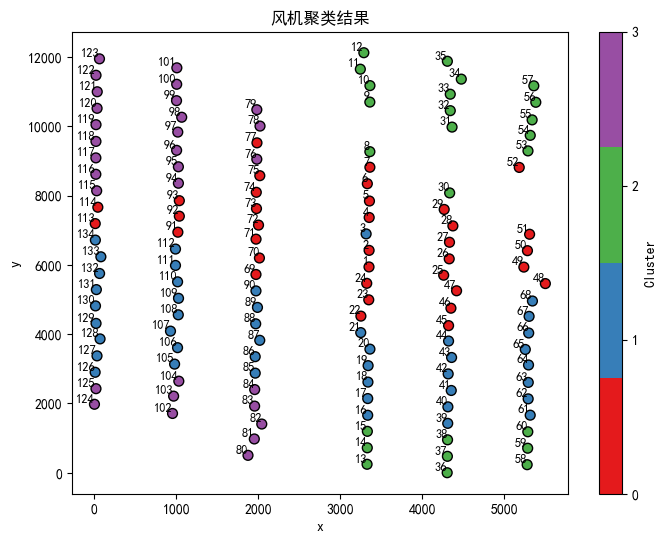

In [4]:
wind_speed_diff_correlation_matrices = np.load("wind_speed_diff_correlation_matrices.npz")["original"]

# 设定聚类数目
n_clusters = 4

# 使用K-means进行聚类
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(wind_speed_diff_correlation_matrices)

print("聚类标签:", labels)
draw_cluster(labels, n_clusters)

## 三. 利用风向计算相关性进行聚类

聚类标签: [0 0 0 0 0 0 0 0 0 0 2 2 0 2 2 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2
 2 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 0 0 0 0 0 0
 0 0 2 2 2 2 2 2 2 2 2 2 1 1 1 1 0 0 0 0 0 0 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1
 1 0 0 0 0 0 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1]


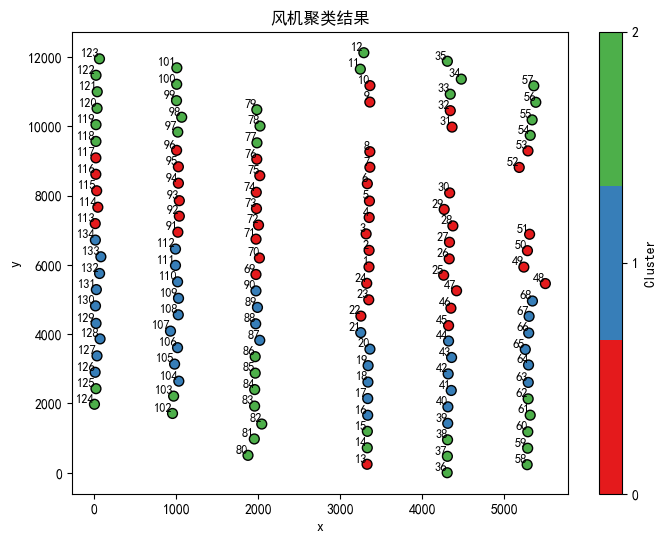

In [5]:
wind_direction_correlation_matrices = np.load("wind_direction_correlation_matrices.npz")["original"]

# 设定聚类数目
n_clusters = 3

# 使用K-means进行聚类
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(wind_direction_correlation_matrices)

print("聚类标签:", labels)
draw_cluster(labels, n_clusters)

## 四. 利用加权平均计算相关性进行聚类

聚类标签: [0 0 3 0 0 0 0 0 0 0 0 2 0 2 2 3 3 3 3 3 3 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2
 2 3 3 3 3 3 3 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 1 1 1 1 1 3 3 3 3 0 0 0 0 0 0
 0 2 0 2 2 2 2 2 1 1 1 1 1 1 3 3 0 0 0 0 2 2 2 2 2 2 2 1 1 1 1 1 1 3 3 3 3
 3 0 0 0 0 2 2 2 2 2 2 1 1 1 1 1 1 1 3 3 3 3 3]


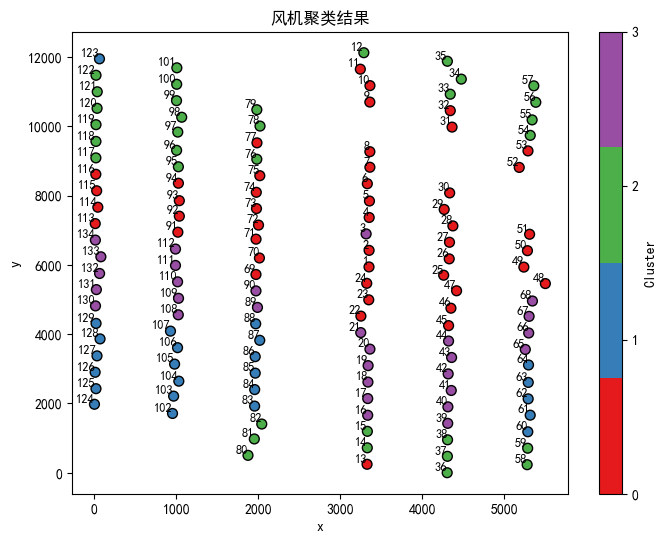

每一类的数量: {0: 47, 1: 24, 2: 34, 3: 29}


In [6]:
wind_speed_correlation_matrices = np.load("wind_speed_correlation_matrices.npz")["original"]
wind_speed_diff_correlation_matrices = np.load("wind_speed_diff_correlation_matrices.npz")["original"]
wind_direction_correlation_matrices = np.load("wind_direction_correlation_matrices.npz")["original"]

a,b,c = 0.2, 0.4, 0.4
weighted_correlation_matrix = a * wind_speed_correlation_matrices + b * wind_speed_diff_correlation_matrices + c * wind_direction_correlation_matrices

# 设定聚类数目
n_clusters = 4

# 使用K-means进行聚类
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(weighted_correlation_matrix)

print("聚类标签:", labels)
draw_cluster(labels, n_clusters)

#统计每一类的数量
unique, counts = np.unique(labels, return_counts=True)
cluster_counts = dict(zip(map(int, unique), map(int, counts)))
print("每一类的数量:", cluster_counts)
np.savez("weighted_correlation_matrix.npz", original=weighted_correlation_matrix)

In [7]:
## 选取标签为3的风机
selected_turbines = np.where(labels == 3)[0]
print("选取的风机索引:", selected_turbines+1)

选取的风机索引: [  3  16  17  18  19  20  21  39  40  41  42  43  44  65  66  67  68  89
  90 108 109 110 111 112 130 131 132 133 134]


In [15]:
# 保存每一类风机的TurbID到npy文件
turbine_cluster = []
for label in range(n_clusters):
    turbines_in_cluster = np.where(labels == label)[0] # TurbID从1开始
    turbine_cluster.append(turbines_in_cluster)
print([arr.shape for arr in turbine_cluster])
turbine_cluster = np.array(turbine_cluster, dtype=object)
print(turbine_cluster)
print(turbine_cluster.shape)
np.save("node_index.npy", turbine_cluster)

[(47,), (24,), (34,), (29,)]
[array([  0,   1,   3,   4,   5,   6,   7,   8,   9,  10,  12,  21,  22,
         23,  24,  25,  26,  27,  28,  29,  30,  31,  44,  45,  46,  47,
         48,  49,  50,  51,  52,  68,  69,  70,  71,  72,  73,  74,  76,
         90,  91,  92,  93, 112, 113, 114, 115])
 array([ 59,  60,  61,  62,  63,  82,  83,  84,  85,  86,  87, 101, 102,
        103, 104, 105, 106, 122, 123, 124, 125, 126, 127, 128])
 array([ 11,  13,  14,  32,  33,  34,  35,  36,  37,  53,  54,  55,  56,
         57,  58,  75,  77,  78,  79,  80,  81,  94,  95,  96,  97,  98,
         99, 100, 116, 117, 118, 119, 120, 121])
 array([  2,  15,  16,  17,  18,  19,  20,  38,  39,  40,  41,  42,  43,
         64,  65,  66,  67,  88,  89, 107, 108, 109, 110, 111, 129, 130,
        131, 132, 133])                                                 ]
(4,)
